# CQF Exam 2 Kai Eric Riemenschneider #

In [68]:
import numpy as np
from typing import NamedTuple
import pandas as pd
from typing import NamedTuple, Callable
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import HTML, display

In [69]:
# Define the SimulationRecord as a NamedTuple
class SimulationRecord(NamedTuple):
    prices: np.ndarray  # Matrix of shape (num_paths, num_steps)
    times: np.ndarray   # Time grida
    scheme_name: str
    parameters: dict

# Define parameter set as a NamedTuple
class ParameterSet(NamedTuple):
    S0: float           # Today's stock price
    E: float            # Strike price
    T: float            # Time to expiry (in years)
    sigma: float        # Volatility
    r: float            # Risk-free interest rate
    num_paths: int      # Number of simulation paths
    num_steps: int      # Number of time steps

# Create default parameter set
def create_default_parameters(
    S0: float = 100,
    E: float = 100,
    T: float = 1.0,
    sigma: float = 0.20,
    r: float = 0.05,
    num_paths: int = 10000,
    num_steps: int = 252
) -> ParameterSet:
    return ParameterSet(
        S0=S0,
        E=E,
        T=T,
        sigma=sigma,
        r=r,
        num_paths=num_paths,
        num_steps=num_steps
    )


In [70]:
# Closed Form Solution
def simulate_closed_form(params: ParameterSet, use_antithetic: bool = False) -> SimulationRecord:
    """
    Simulate stock prices using the closed form solution of GBM.
    
    Formula: S_{t+dt} = S_t * exp((r - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
    where Z ~ N(0,1) is a DIFFERENT random number for each time step.
    
    This is the exact solution for Geometric Brownian Motion with time stepping.
    Each step builds on the previous price (not from S_0).
    """
    np.random.seed(42)
    
    dt                = params.T / params.num_steps
    times             = np.linspace(0, params.T, params.num_steps + 1)
    
    num_paths         = params.num_paths if not use_antithetic else params.num_paths // 2
    Z                 = np.random.standard_normal((num_paths, params.num_steps))
    
    if use_antithetic:
        Z              = np.vstack([Z, -Z])
    
    prices            = np.zeros((Z.shape[0], params.num_steps + 1))
    prices[:, 0]      = params.S0
    
    drift             = (params.r - 0.5 * params.sigma**2) * dt
    diffusion_coeff   = params.sigma * np.sqrt(dt)
    
    for step in range(1, params.num_steps + 1):
        # Build on PREVIOUS price, not S_0
        prices[:, step] = prices[:, step - 1] * np.exp(
            drift + diffusion_coeff * Z[:, step - 1]
        )
    
    return SimulationRecord(
        prices=prices,
        times=times,
        scheme_name="Closed Form",
        parameters=params._asdict()
    )

# Euler-Maruyama Scheme
def simulate_euler_maruyama(params: ParameterSet, use_antithetic: bool = False) -> SimulationRecord:
    np.random.seed(42)
    
    dt                = params.T / params.num_steps
    times             = np.linspace(0, params.T, params.num_steps + 1)
    
    num_paths         = params.num_paths if not use_antithetic else params.num_paths // 2
    phi               = np.random.standard_normal((num_paths, params.num_steps))
    
    if use_antithetic:
        phi            = np.vstack([phi, -phi])
    
    prices            = np.zeros((phi.shape[0], params.num_steps + 1))
    prices[:, 0]      = params.S0
    
    sqrt_dt           = np.sqrt(dt)
    increments        = 1 + params.r * dt + params.sigma * phi * sqrt_dt
    
    for step in range(params.num_steps):
        prices[:, step + 1] = prices[:, step] * increments[:, step]
    
    return SimulationRecord(
        prices=prices,
        times=times,
        scheme_name="Euler-Maruyama",
        parameters=params._asdict()
    )

# Milstein Scheme
def simulate_milstein(params: ParameterSet, use_antithetic: bool = False) -> SimulationRecord:
    np.random.seed(42)
    
    dt                = params.T / params.num_steps
    times             = np.linspace(0, params.T, params.num_steps + 1)
    
    num_paths         = params.num_paths if not use_antithetic else params.num_paths // 2
    phi               = np.random.standard_normal((num_paths, params.num_steps))
    
    if use_antithetic:
        phi            = np.vstack([phi, -phi])
    
    prices            = np.zeros((phi.shape[0], params.num_steps + 1))
    prices[:, 0]      = params.S0
    
    sqrt_dt             = np.sqrt(dt)
    milstein_correction = 0.5 * params.sigma**2 * (phi**2 - 1) * dt
    increments          = 1 + params.r * dt + params.sigma * phi * sqrt_dt + milstein_correction
    
    for step in range(params.num_steps):
        prices[:, step + 1] = prices[:, step] * increments[:, step]
    
    return SimulationRecord(
        prices=prices,
        times=times,
        scheme_name="Milstein",
        parameters=params._asdict()
    )


In [71]:
def european_call_payoff(S_T: np.ndarray, E: float, use_antithetic: bool = False) -> np.ndarray:
    """European call payoff: max(S_T - E, 0)"""
    payoff = np.maximum(S_T - E, 0)
    if use_antithetic:
        num_original = len(payoff) // 2
        payoff_original = payoff[:num_original]
        payoff_antithetic = payoff[num_original:]
        payoff = (payoff_original + payoff_antithetic) / 2
    return payoff

def european_put_payoff(S_T: np.ndarray, E: float, use_antithetic: bool = False) -> np.ndarray:
    """European put payoff: max(E - S_T, 0)"""
    payoff = np.maximum(E - S_T, 0)
    if use_antithetic:
        num_original = len(payoff) // 2
        payoff_original = payoff[:num_original]
        payoff_antithetic = payoff[num_original:]
        payoff = (payoff_original + payoff_antithetic) / 2
    return payoff

def binary_call_payoff(S_T: np.ndarray, E: float, use_antithetic: bool = False) -> np.ndarray:
    """Binary call payoff: 1 if S_T > E, else 0"""
    payoff = (S_T > E).astype(float)
    if use_antithetic:
        num_original = len(payoff) // 2
        payoff_original = payoff[:num_original]
        payoff_antithetic = payoff[num_original:]
        payoff = (payoff_original + payoff_antithetic) / 2
    return payoff

def binary_put_payoff(S_T: np.ndarray, E: float, use_antithetic: bool = False) -> np.ndarray:
    """Binary put payoff: 1 if S_T < E, else 0"""
    payoff = (S_T < E).astype(float)
    if use_antithetic:
        num_original = len(payoff) // 2
        payoff_original = payoff[:num_original]
        payoff_antithetic = payoff[num_original:]
        payoff = (payoff_original + payoff_antithetic) / 2
    return payoff

def price_option(
    simulation_record: SimulationRecord,
    payoff_func: Callable[[np.ndarray, float, bool], np.ndarray],
    use_antithetic: bool = False
) -> tuple:
    S_T = simulation_record.prices[:, -1]
    payoffs = payoff_func(S_T, simulation_record.parameters['E'], use_antithetic=use_antithetic)
    
    r = simulation_record.parameters['r']
    T = simulation_record.parameters['T']
    discount_factor = np.exp(-r * T)
    
    discounted_payoffs = discount_factor * payoffs
    option_price = np.mean(discounted_payoffs)
    std_error = np.std(discounted_payoffs) / np.sqrt(len(payoffs))
    
    return option_price, std_error



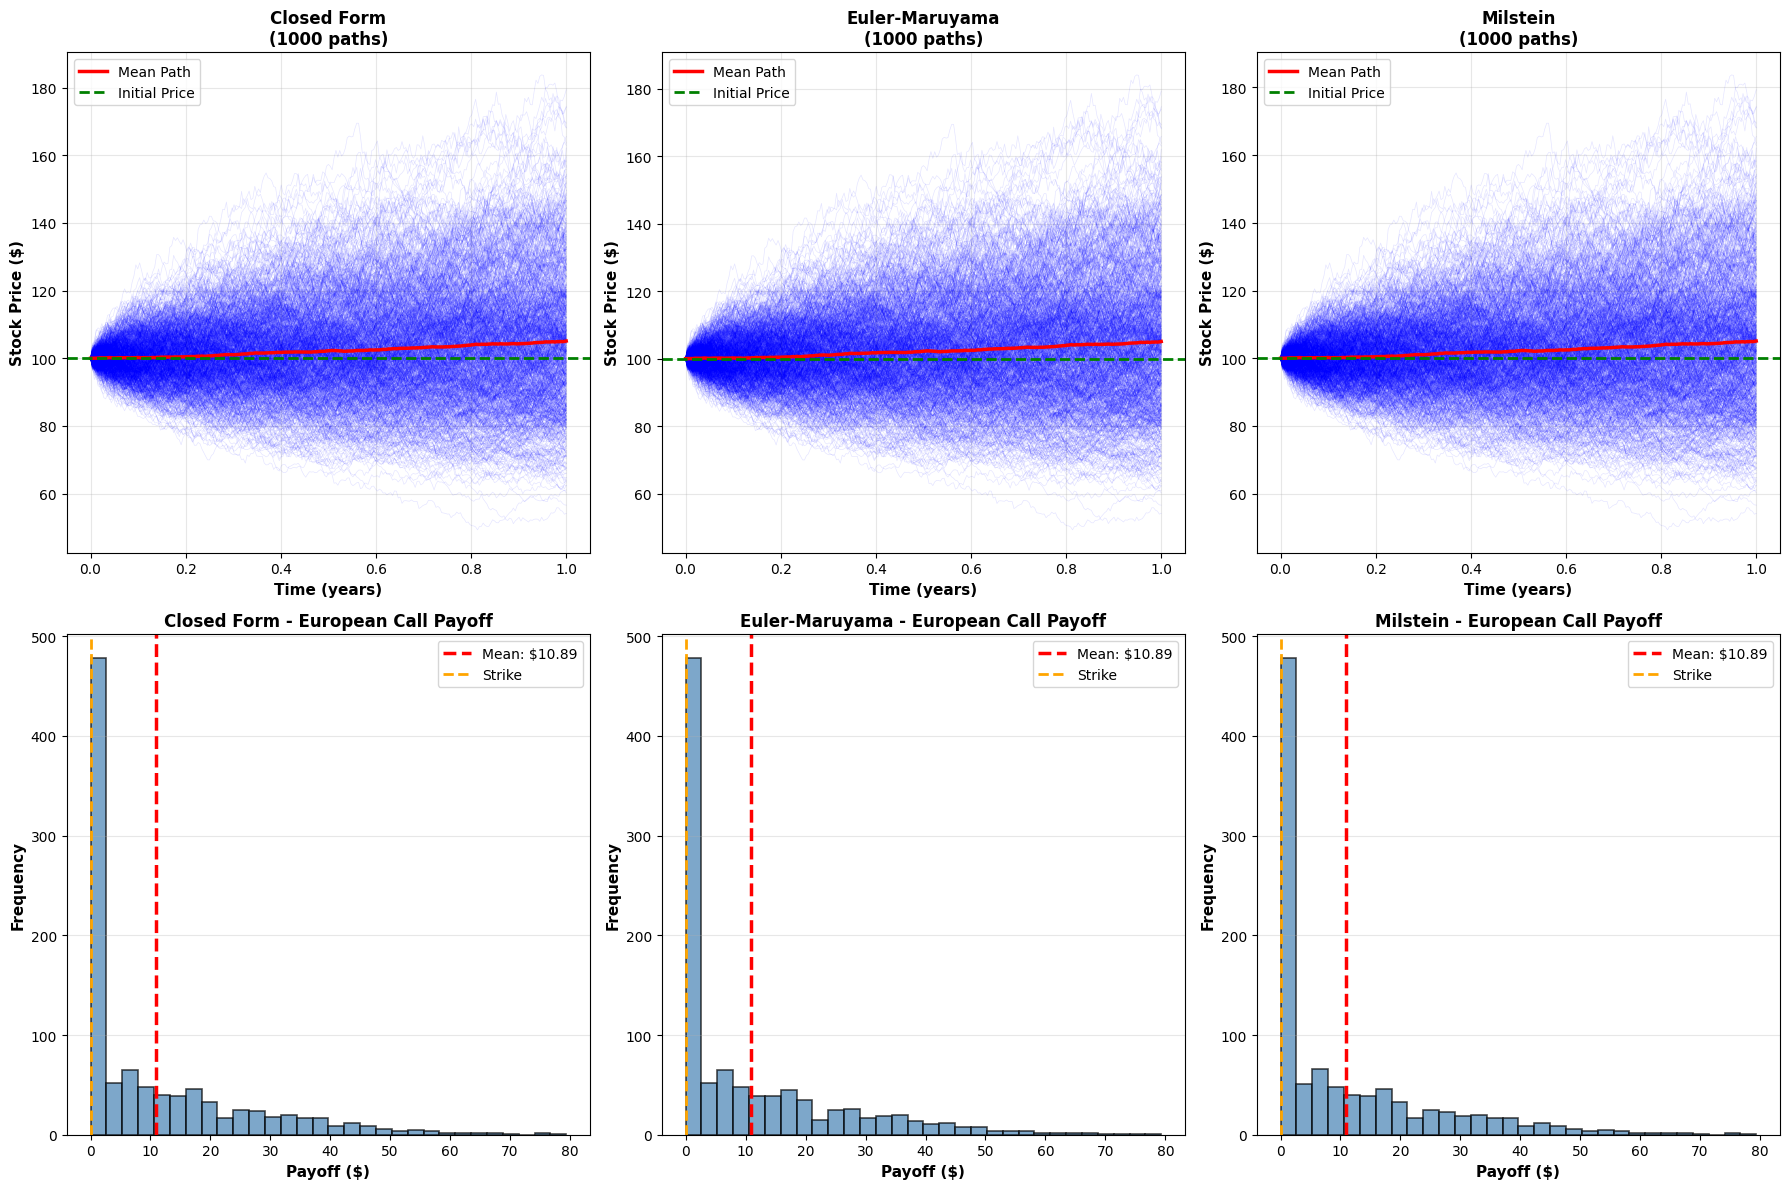

In [72]:
params = create_default_parameters(num_paths=1000, num_steps=252)

cf_sim = simulate_closed_form(params)
em_sim = simulate_euler_maruyama(params)
mil_sim = simulate_milstein(params)

payoff_funcs = {
    'european_call': european_call_payoff,
    'european_put': european_put_payoff,
    'binary_call': binary_call_payoff,
    'binary_put': binary_put_payoff,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: Price paths
for idx, (sim, title) in enumerate([(cf_sim, 'Closed Form'), 
                                      (em_sim, 'Euler-Maruyama'), 
                                      (mil_sim, 'Milstein')]):
    ax = axes[0, idx]
    
    for path in range(sim.prices.shape[0]):
        ax.plot(sim.times, sim.prices[path, :], alpha=0.1, color='blue', linewidth=0.5)
    
    ax.plot(sim.times, np.mean(sim.prices, axis=0), color='red', linewidth=2.5, label='Mean Path')
    ax.axhline(y=params.S0, color='green', linestyle='--', linewidth=2, label='Initial Price')
    
    ax.set_xlabel('Time (years)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Stock Price ($)', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\n({params.num_paths} paths)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# Bottom row: Payoff histograms at expiration
for idx, (sim, title) in enumerate([(cf_sim, 'Closed Form'), 
                                      (em_sim, 'Euler-Maruyama'), 
                                      (mil_sim, 'Milstein')]):
    ax = axes[1, idx]
    
    S_T = sim.prices[:, -1]
    payoffs = european_call_payoff(S_T, params.E, use_antithetic=False)
    
    ax.hist(payoffs, bins=30, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.2)
    ax.axvline(x=np.mean(payoffs), color='red', linestyle='--', linewidth=2.5, label=f'Mean: ${np.mean(payoffs):.2f}')
    ax.axvline(x=0, color='orange', linestyle='--', linewidth=2, label='Strike')
    
    ax.set_xlabel('Payoff ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{title} - European Call Payoff', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


# 1. Introduction

## 1.1 Finance Problem

This project addresses the pricing of European and binary (digital) call options using Monte Carlo simulation under the **risk‑neutral valuation framework**. Under the risk-neutral measure $\mathbb{Q}$, the arbitrage‑free price of a derivative with maturity $T$ is:

$$
V(S,t) = e^{-r(T-t)}\,\mathbb{E}^{\mathbb{Q}}[\text{Payoff}(S_T)],
$$

following standard arbitrage arguments [1,2].

The payoff functions considered are:

- **European Call**  
  $$
  \text{Payoff} = \max(S_T - E, 0),
  $$
  (smooth, continuous payoff [1,2])

- **Binary Call**  
  $$
  \text{Payoff} =
  \begin{cases}
  1, & S_T > E, \\
  0, & S_T \le E,
  \end{cases}
  $$
  which introduces a **discontinuity** at the strike and is notoriously sensitive to numerical error [5,6].

---

## 1.2 Underlying Stock Price Dynamics

We assume the underlying asset follows **Geometric Brownian Motion (GBM)** under $\mathbb{Q}$:

$$
dS_t = rS_t\,dt + \sigma S_t\, dW_t,
$$

with constant volatility and drift [1,2].  
This SDE admits the closed‑form solution:

$$
S_T = S_0 \exp\left[\left(r-\tfrac12\sigma^2\right)(T-t) + \sigma\sqrt{T-t}\,Z\right],\quad Z \sim N(0,1),
$$

which allows **exact simulation** without discretisation error [1,7].

These expressions are explicitly reproduced in the CQF Milstein resource PDF [14].

---

## 1.3 Numerical Procedures

Monte Carlo simulation generates $N$ independent paths, computes the payoff on each, and averages them.  
We compare **three simulation schemes**, each with its own convergence order [3,4,14].

Before comparing the schemes, two fundamental convergence notions apply [3,4]:

- **Strong convergence** — accuracy of sample paths  
- **Weak convergence** — accuracy of expectations (option prices)

This classification determines why Milstein outperforms EM in path‑dependent or discontinuous payoffs.

---

## 1.4 Closed‑Form Simulation (Exact GBM Sampling)

Using the exact GBM solution [1,2]:

$$
S_T = S_0 \exp\left[(r - 0.5\,\sigma^2)\tau + \sigma\sqrt{\tau}\,Z\right],
$$

we obtain:

- **Zero discretisation error**  
- Exact lognormal distribution [1]  
- Fastest and most numerically stable method [7]

This is the natural benchmark for testing numerical SDE schemes.

---

## 1.5 Euler–Maruyama Scheme

A first‑order explicit discretisation [3,4,14]:

$$
S_{t+\Delta t}
= S_t\left(1 + r\Delta t + \sigma\phi\sqrt{\Delta t}\right),
\quad \phi \sim N(0,1).
$$

Euler–Maruyama is a **linear approximation** to the exponential GBM dynamics and **omits** the Itô correction term, as shown in the CQF resource [14]:

$$
\tfrac12 \sigma^2 (\phi^2 - 1)\Delta t.
$$

### Convergence properties
- **Strong order:**  
  $$O(\Delta t^{1/2})$$
- **Weak order:**  
  $$O(\Delta t)$$  
  (classical results from [3,4])

### Practical effects of missing the correction term  
As documented in [3,4,14]:

- Variance misestimation  
- Systematic underpricing (from $e^x > 1 + x$)  
- Accumulating drift bias  
- Amplified error for long maturities or discontinuous payoffs (binary options) [5,6]

---

## 1.6 Milstein Scheme

The Milstein method includes the Itô–Taylor correction [3,4,14]:

$$
S_{t+\Delta t} =
S_t\left(
1 + r\Delta t
+ \sigma\phi\sqrt{\Delta t}
+ \tfrac12\sigma^2(\phi^2 - 1)\Delta t
\right).
$$

This correction appears explicitly in the attached PDF [14], which also derives it via the Taylor expansion of the exact GBM solution.

### Convergence properties
- **Strong order:**  
  $$O(\Delta t)$$
- **Weak order:**  
  $$O(\Delta t)$$  

As a result, Milstein more accurately reproduces GBM variance and tail behaviour, which is crucial for binary/digital options [5,6,7].

---

## 1.7 Monte Carlo Sampling Error Theory

Regardless of discretisation scheme, Monte Carlo introduces sampling error:

$$
\text{StdErr}(\hat{V}_N) = \frac{\sqrt{\operatorname{Var}[X]}}{\sqrt{N}}.
$$

Thus:

- Sampling error scales as **$1/\sqrt{N}$**, due to the Central Limit Theorem [8].
- This rate is **independent of the SDE discretisation method**, as long as the scheme produces approximately i.i.d. payoff samples [9].
- Closed‑form, EM, and Milstein therefore share **the same sampling‑error slope**.

---

## 1.8 Variance Reduction: Antithetic Variates

Antithetic variates reduce variance by inducing **negative covariance** between $f(Z)$ and $f(-Z)$ [10,13]:

$$
\hat{V}_{\text{anti}} = \frac{1}{2}(f(Z) + f(-Z)).
$$

This technique is:

- **Moderately effective** for smooth European payoffs [10,11]  
- **Highly effective** for discontinuous binary payoffs [12]

and does **not** depend on the discretisation scheme [13].

---

## 1.9 Implementation Strategy

1. Define simulation parameters using a `ParameterSet`.  
2. Implement: Closed‑form GBM, Euler–Maruyama, and Milstein.  
3. Price options via discounted expected payoffs.  
4. Add antithetic variates (optional).  
5. Run two experiments: parameter sweeps and sampling‑error analysis.  
6. Compare accuracy, convergence, and efficiency.

---

## Baseline Parameters

- $S_0 = 100$  
- $E = 100$  
- $T = 1$ year  
- $\Delta t = 1/252$  
- $\sigma = 20\%$  
- $r = 5\%$  
- $N = 1000$ Monte‑Carlo paths  


# 2. Parameter Sweep Experiments 

In [73]:
base_params = create_default_parameters(num_paths=1000, num_steps=252)

sweep_ranges = {
    'S0':       np.linspace(0, 2 * base_params.S0, 41),
    'E':        np.linspace(0, 2 * base_params.E, 41),
    'T':        np.linspace(0.01, 2 * base_params.T, 41),
    'sigma':    np.linspace(0.01, 2 * base_params.sigma, 41),
    'r':        np.linspace(0, 2 * base_params.r, 41),
    'num_steps': np.linspace(50, 1000, 41, dtype=int),
}

param_names = ['S0', 'E', 'T', 'sigma', 'r', 'num_steps']
payoff_funcs = {'european_call': european_call_payoff, 'binary_call': binary_call_payoff}

sweep_results = {}

def parameter_sweep_with_errors(
    param_name: str,
    sweep_range: np.ndarray,
    base_params: ParameterSet,
    payoff_func: Callable,
    num_paths: int = 1000,
    num_steps: int = 252
) -> dict:
    
    results = {
        'sweep_values': sweep_range,
        'closed_form': [],
        'euler_maruyama': [],
        'milstein': [],
        'closed_form_se': [],
        'euler_maruyama_se': [],
        'milstein_se': []
    }
    
    for value in sweep_range:
        params_dict = base_params._asdict()
        params_dict[param_name] = value
        params_dict['num_paths'] = num_paths
        if param_name != 'num_steps':
            params_dict['num_steps'] = num_steps
        params = ParameterSet(**params_dict)
        
        cf_sim = simulate_closed_form(params, use_antithetic=False)
        em_sim = simulate_euler_maruyama(params, use_antithetic=False)
        mil_sim = simulate_milstein(params, use_antithetic=False)
        
        cf_price, cf_se = price_option(cf_sim, payoff_func, use_antithetic=False)
        em_price, em_se = price_option(em_sim, payoff_func, use_antithetic=False)
        mil_price, mil_se = price_option(mil_sim, payoff_func, use_antithetic=False)
        
        results['closed_form'].append(cf_price)
        results['euler_maruyama'].append(em_price)
        results['milstein'].append(mil_price)
        results['closed_form_se'].append(cf_se)
        results['euler_maruyama_se'].append(em_se)
        results['milstein_se'].append(mil_se)
    
    return results

for payoff_name, payoff_func in payoff_funcs.items():
    for param_name in param_names:
        key = f"{payoff_name}_{param_name}"
        results = parameter_sweep_with_errors(
            param_name=param_name,
            sweep_range=sweep_ranges[param_name],
            base_params=base_params,
            payoff_func=payoff_func,
            num_paths=1000,
            num_steps=252
        )
        sweep_results[key] = results

param_labels = {
    'S0':        'Stock Price S₀ (% of base value)',
    'E':         'Strike Price E (% of base value)',
    'T':         'Time to Expiry T (% of base value)',
    'sigma':     'Volatility σ (% of base value)',
    'r':         'Risk-free Rate r (% of base value)',
    'num_steps': 'Number of Steps'
}


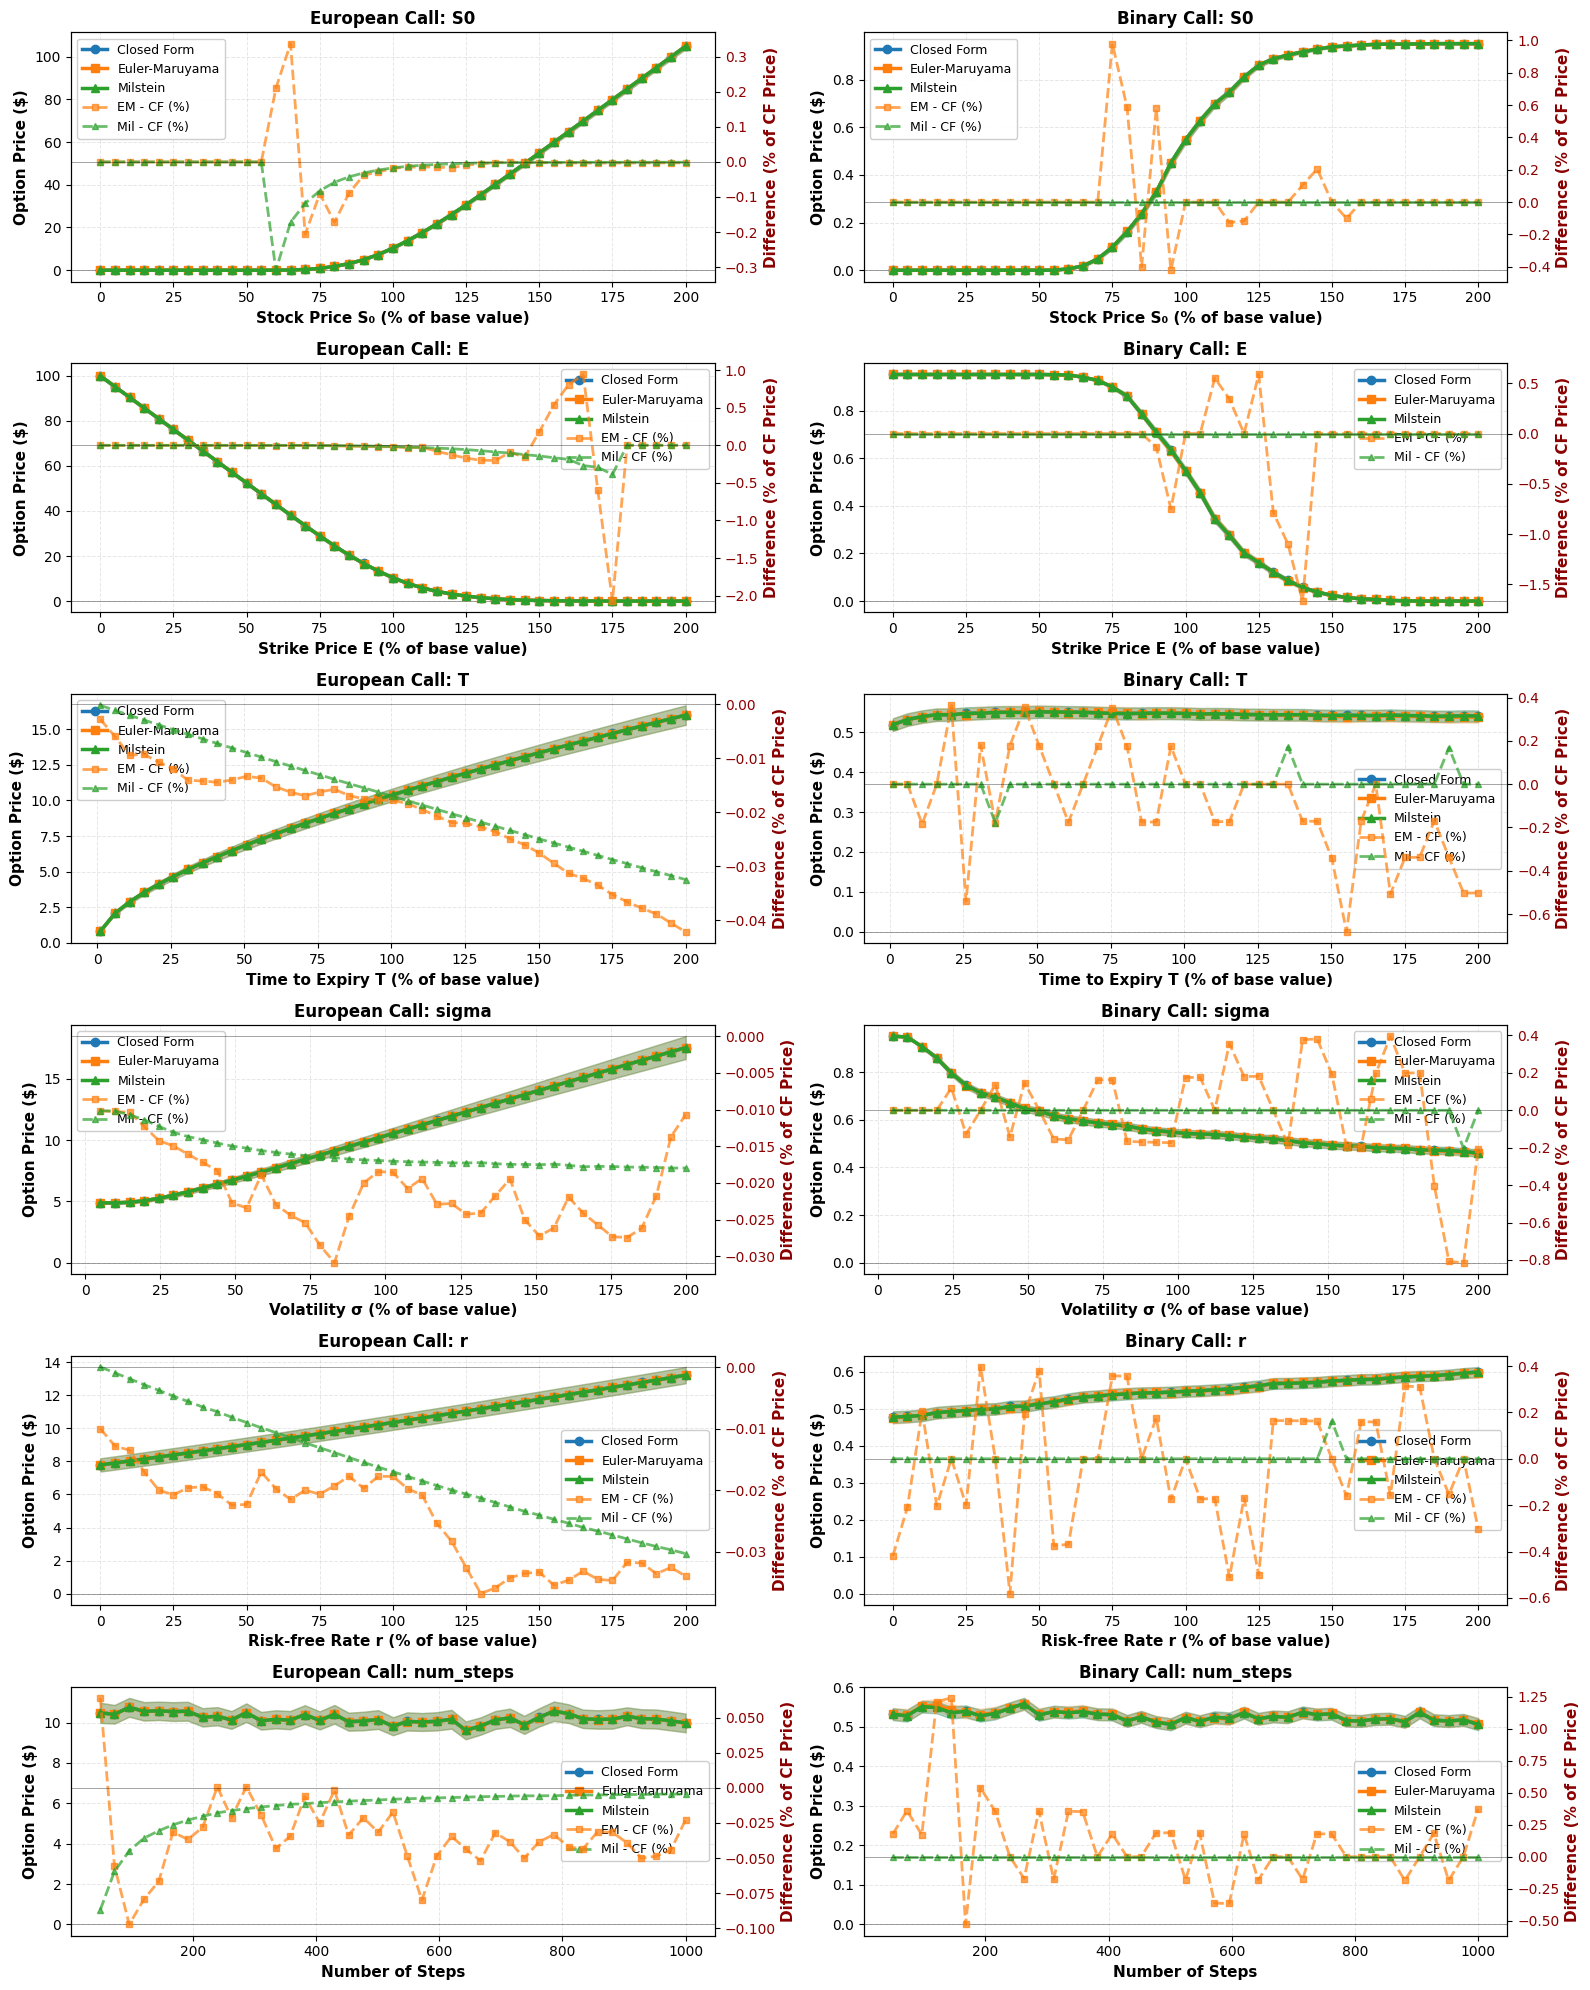

In [74]:
colors = {'closed_form': '#1f77b4', 'euler_maruyama': '#ff7f0e', 'milstein': '#2ca02c'}

fig, axes = plt.subplots(6, 2, figsize=(16, 20))

for row, param_name in enumerate(param_names):
    for col, payoff_name in enumerate(payoff_funcs.keys()):
        ax = axes[row, col]
        ax_right = ax.twinx()
        
        key = f"{payoff_name}_{param_name}"
        results = sweep_results[key]
        
        sweep_vals = np.array(results['sweep_values'])
        cf_prices = np.array(results['closed_form'])
        em_prices = np.array(results['euler_maruyama'])
        mil_prices = np.array(results['milstein'])
        cf_se = np.array(results['closed_form_se'])
        em_se = np.array(results['euler_maruyama_se'])
        mil_se = np.array(results['milstein_se'])
        
        # Handle num_steps differently (no percentage conversion)
        if param_name == 'num_steps':
            sweep_pct = sweep_vals
            ax.set_xlabel(param_labels[param_name], fontsize=11, fontweight='bold')
        else:
            base_val = base_params._asdict()[param_name]
            sweep_pct = (sweep_vals / base_val) * 100
            ax.set_xlabel(param_labels[param_name], fontsize=11, fontweight='bold')
        
        # Left axis: absolute prices
        ax.plot(sweep_pct, cf_prices, 'o-', linewidth=2.5, markersize=6, 
                label='Closed Form', color=colors['closed_form'], zorder=3)
        ax.fill_between(sweep_pct, cf_prices - cf_se, cf_prices + cf_se, 
                         alpha=0.2, color=colors['closed_form'], zorder=1)
        
        ax.plot(sweep_pct, em_prices, 's-', linewidth=2.5, markersize=6, 
                label='Euler-Maruyama', color=colors['euler_maruyama'], zorder=3)
        ax.fill_between(sweep_pct, em_prices - em_se, em_prices + em_se, 
                         alpha=0.2, color=colors['euler_maruyama'], zorder=1)
        
        ax.plot(sweep_pct, mil_prices, '^-', linewidth=2.5, markersize=6, 
                label='Milstein', color=colors['milstein'], zorder=3)
        ax.fill_between(sweep_pct, mil_prices - mil_se, mil_prices + mil_se, 
                         alpha=0.2, color=colors['milstein'], zorder=1)
        
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        
        ax.set_ylabel('Option Price ($)', fontsize=11, fontweight='bold', color='black')
        ax.tick_params(axis='y', labelcolor='black')
        
        # Right axis: percentage differences
        diff_em_pct = np.divide((em_prices - cf_prices), cf_prices, where=cf_prices!=0, out=np.zeros_like(cf_prices)) * 100
        diff_mil_pct = np.divide((mil_prices - cf_prices), cf_prices, where=cf_prices!=0, out=np.zeros_like(cf_prices)) * 100
        
        ax_right.plot(sweep_pct, diff_em_pct, 's--', linewidth=2, markersize=5, 
                      label='EM - CF (%)', color=colors['euler_maruyama'], alpha=0.7, zorder=2)
        ax_right.plot(sweep_pct, diff_mil_pct, '^--', linewidth=2, markersize=5, 
                      label='Mil - CF (%)', color=colors['milstein'], alpha=0.7, zorder=2)
        
        ax_right.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        ax_right.set_ylabel('Difference (% of CF Price)', fontsize=11, fontweight='bold', color='darkred')
        ax_right.tick_params(axis='y', labelcolor='darkred')
        
        ax.set_title(f'{payoff_name.replace("_", " ").title()}: {param_name}', 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
        ax.set_axisbelow(True)
        
        # Combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax_right.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='best', framealpha=0.95)

plt.tight_layout()
plt.show()


In [75]:
table_data = []

for param_name in param_names:
    for payoff_name in payoff_funcs.keys():
        key = f"{payoff_name}_{param_name}"
        results = sweep_results[key]
        
        sweep_vals = np.array(results['sweep_values'])
        cf_prices = np.array(results['closed_form'])
        em_prices = np.array(results['euler_maruyama'])
        mil_prices = np.array(results['milstein'])
        cf_se = np.array(results['closed_form_se'])
        em_se = np.array(results['euler_maruyama_se'])
        mil_se = np.array(results['milstein_se'])
        
        # Handle num_steps differently (no percentage conversion)
        if param_name == 'num_steps':
            sweep_display = sweep_vals.astype(int)
        else:
            base_val = base_params._asdict()[param_name]
            sweep_display = (sweep_vals / base_val) * 100
        
        # Calculate differences
        diff_em_pct = np.divide((em_prices - cf_prices), cf_prices, where=cf_prices!=0, out=np.zeros_like(cf_prices)) * 100
        diff_mil_pct = np.divide((mil_prices - cf_prices), cf_prices, where=cf_prices!=0, out=np.zeros_like(cf_prices)) * 100
        
        for i, sweep_val in enumerate(sweep_display):
            table_data.append({
                'Payoff':           payoff_name.replace('_', ' ').title(),
                'Parameter':        param_name,
                'Sweep Value':      f"{sweep_val:.2f}" if param_name != 'num_steps' else f"{int(sweep_val)}",
                'CF Price ($)':     f"{cf_prices[i]:.4f}",
                'CF SE ($)':        f"{cf_se[i]:.4f}",
                'EM Price ($)':     f"{em_prices[i]:.4f}",
                'EM SE ($)':        f"{em_se[i]:.4f}",
                'EM Error (%)':     f"{diff_em_pct[i]:.4f}",
                'Mil Price ($)':    f"{mil_prices[i]:.4f}",
                'Mil SE ($)':       f"{mil_se[i]:.4f}",
                'Mil Error (%)':    f"{diff_mil_pct[i]:.4f}",
            })

df = pd.DataFrame(table_data)
print(df.to_string(index=False))

       Payoff Parameter Sweep Value CF Price ($) CF SE ($) EM Price ($) EM SE ($) EM Error (%) Mil Price ($) Mil SE ($) Mil Error (%)
European Call        S0        0.00       0.0000    0.0000       0.0000    0.0000       0.0000        0.0000     0.0000        0.0000
European Call        S0        5.00       0.0000    0.0000       0.0000    0.0000       0.0000        0.0000     0.0000        0.0000
European Call        S0       10.00       0.0000    0.0000       0.0000    0.0000       0.0000        0.0000     0.0000        0.0000
European Call        S0       15.00       0.0000    0.0000       0.0000    0.0000       0.0000        0.0000     0.0000        0.0000
European Call        S0       20.00       0.0000    0.0000       0.0000    0.0000       0.0000        0.0000     0.0000        0.0000
European Call        S0       25.00       0.0000    0.0000       0.0000    0.0000       0.0000        0.0000     0.0000        0.0000
European Call        S0       30.00       0.0000    0.0000    

In [76]:
# Display both tables as styled HTML
def display_styled_table(df, title):
    """Display a pandas DataFrame as a styled HTML table."""
    styled = df.style.format(precision=4).set_properties(
        **{'text-align': 'center', 'border': '1px solid black'}
    ).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4472C4'), 
                                     ('color', 'white'), 
                                     ('font-weight', 'bold'),
                                     ('text-align', 'center'),
                                     ('border', '1px solid black')]},
        {'selector': 'td', 'props': [('border', '1px solid black'),
                                     ('padding', '8px')]},
        {'selector': '', 'props': [('border-collapse', 'collapse')]}
    ])
    
    display(HTML(f"<h3>{title}</h3>"))
    display(styled)

In [77]:
def compute_error_statistics(sweep_results, param_names, payoff_funcs):
    """Compute error statistics for EM and Milstein vs Closed Form."""
    stats_data = []
    
    for param_name in param_names:
        for payoff_name in payoff_funcs.keys():
            key = f"{payoff_name}_{param_name}"
            results = sweep_results[key]
            
            cf_prices = np.array(results['closed_form'])
            em_prices = np.array(results['euler_maruyama'])
            mil_prices = np.array(results['milstein'])
            
            valid_mask = cf_prices != 0
            if not valid_mask.any():
                continue
            
            cf_avg = cf_prices[valid_mask].mean()
            em_avg = em_prices[valid_mask].mean()
            mil_avg = mil_prices[valid_mask].mean()
            
            stats_data.append({
                'Payoff':        payoff_name.replace('_', ' ').title(),
                'Parameter':     param_name,
                'EM Error (%)':  ((em_avg - cf_avg) / cf_avg) * 100,
                'Mil Error (%)': ((mil_avg - cf_avg) / cf_avg) * 100,
            })
    
    df = pd.DataFrame(stats_data)
    return df.round(4)

df_stats = compute_error_statistics(sweep_results, param_names, payoff_funcs)
# print(df_stats.to_string(index=False))



# Task 2,  Monte‑Carlo Sampling Error vs Number of Paths and Anithetic Variates

In [78]:
base_params = create_default_parameters(num_paths=1000, num_steps=252)

x_axis = np.linspace(1/np.sqrt(100000), 1/np.sqrt(10), 50)
num_samples_range = (1 / x_axis) ** 2
num_samples_range = np.round(num_samples_range).astype(int)


# num_samples_range = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000])
payoff_funcs = {'european_call': european_call_payoff, 'binary_call': binary_call_payoff}
schemes = {'closed_form': simulate_closed_form, 'euler_maruyama': simulate_euler_maruyama, 'milstein': simulate_milstein}

error_results = {}

total_iterations = len(payoff_funcs) * len(schemes) * 2 * len(num_samples_range)

with tqdm(total=total_iterations, desc="Computing errors") as pbar:
    for payoff_name, payoff_func in payoff_funcs.items():
        for scheme_name, scheme_func in schemes.items():
            for antithetic in [False, True]:
                key = f"{payoff_name}_{scheme_name}_antithetic={antithetic}"
                errors = []
                
                for num_samples in num_samples_range:
                    params = base_params._replace(num_paths=num_samples)
                    sim = scheme_func(params, use_antithetic=antithetic)
                    price, std_error = price_option(sim, payoff_func, use_antithetic=antithetic)
                    errors.append(std_error)
                    pbar.update(1)
                
                error_results[key] = errors


Computing errors: 100%|██████████| 600/600 [00:20<00:00, 29.13it/s]


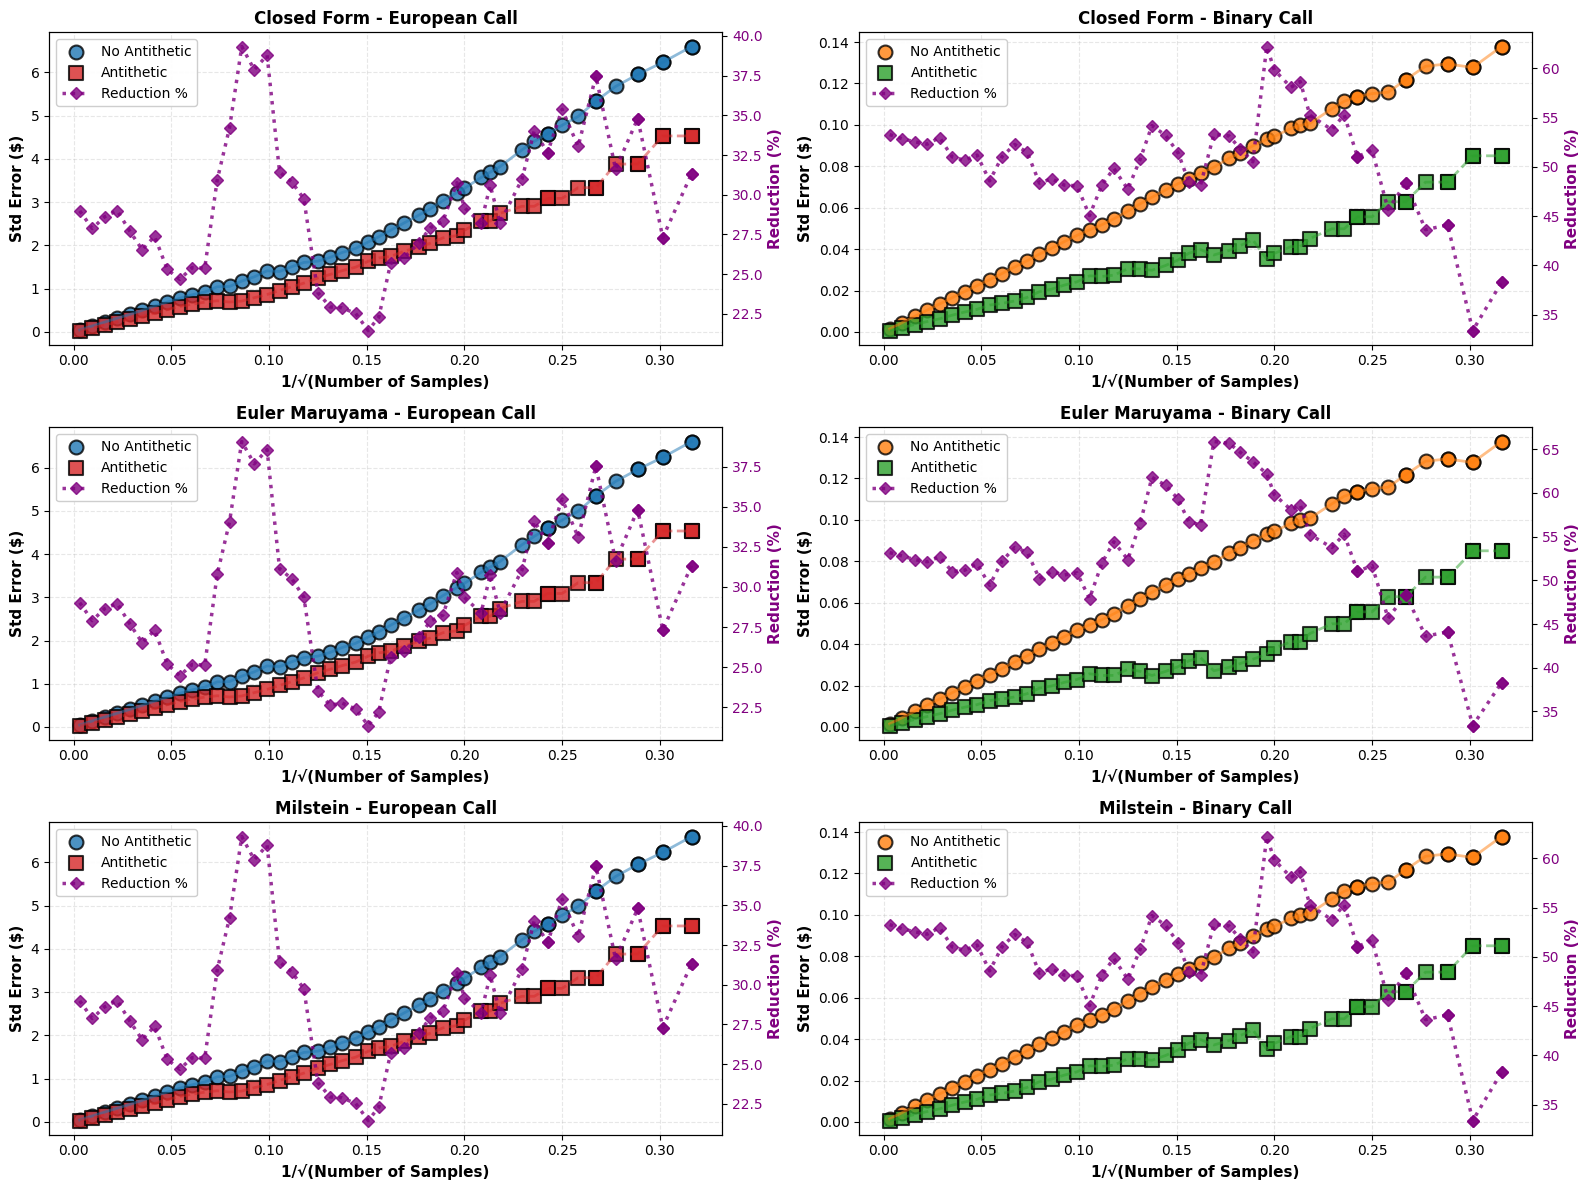

In [79]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

colors_no_anti = {'european_call': '#1f77b4', 'binary_call': '#ff7f0e'}
colors_anti = {'european_call': '#d62728', 'binary_call': '#2ca02c'}

scheme_names_list = list(schemes.keys())

for row, scheme_name in enumerate(scheme_names_list):
    for col, payoff_name in enumerate(payoff_funcs.keys()):
        ax1 = axes[row, col]
        ax2 = ax1.twinx()
        
        key_no_anti = f"{payoff_name}_{scheme_name}_antithetic=False"
        key_anti = f"{payoff_name}_{scheme_name}_antithetic=True"
        
        errors_no_anti = np.array(error_results[key_no_anti])
        errors_anti = np.array(error_results[key_anti])
        
        reduction = ((errors_no_anti - errors_anti) / errors_no_anti) * 100
        
        x_axis = 1/np.sqrt(num_samples_range)
        
        ax1.scatter(x_axis, errors_no_anti, marker='o', s=100,
                    color=colors_no_anti[payoff_name], label='No Antithetic', 
                    alpha=0.8, edgecolors='black', linewidth=1.5)
        ax1.plot(x_axis, errors_no_anti, linestyle='-', 
                 color=colors_no_anti[payoff_name], alpha=0.5, linewidth=2)
        
        ax1.scatter(x_axis, errors_anti, marker='s', s=100,
                    color=colors_anti[payoff_name], label='Antithetic', 
                    alpha=0.8, edgecolors='black', linewidth=1.5)
        ax1.plot(x_axis, errors_anti, linestyle='--', 
                 color=colors_anti[payoff_name], alpha=0.5, linewidth=2)
        
        ax2.plot(x_axis, reduction, marker='D', linestyle=':', 
                 color='purple', linewidth=2.5, markersize=6, label='Reduction %', alpha=0.8)
        
        ax1.set_xlabel('1/√(Number of Samples)', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Std Error ($)', fontsize=11, fontweight='bold', color='black')
        ax2.set_ylabel('Reduction (%)', fontsize=11, fontweight='bold', color='purple')
        ax1.set_title(f'{scheme_name.replace("_", " ").title()} - {payoff_name.replace("_", " ").title()}', 
                      fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.set_axisbelow(True)
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='best', framealpha=0.95)
        
        ax2.tick_params(axis='y', labelcolor='purple')

plt.tight_layout()
plt.savefig('/mnt/data/std_error_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [80]:
table_data = []

scheme_names_list = list(schemes.keys())

for scheme_name in scheme_names_list:
    for payoff_name in payoff_funcs.keys():
        key_no_anti = f"{payoff_name}_{scheme_name}_antithetic=False"
        key_anti = f"{payoff_name}_{scheme_name}_antithetic=True"
        
        errors_no_anti = np.array(error_results[key_no_anti])
        errors_anti = np.array(error_results[key_anti])
        
        reduction = ((errors_no_anti - errors_anti) / errors_no_anti) * 100
        
        for i, num_samples in enumerate(num_samples_range):
            table_data.append({
                'Scheme':                scheme_name.replace('_', ' ').title(),
                'Payoff':                payoff_name.replace('_', ' ').title(),
                'Num Samples':           int(num_samples),
                '1/√N':                  f"{1/np.sqrt(num_samples):.6f}",
                'Error No Anti ($)':     f"{errors_no_anti[i]:.6f}",
                'Error Anti ($)':        f"{errors_anti[i]:.6f}",
                'Reduction (%)':         f"{reduction[i]:.4f}",
            })

df = pd.DataFrame(table_data)
print(df.to_string(index=False))


        Scheme        Payoff  Num Samples     1/√N Error No Anti ($) Error Anti ($) Reduction (%)
   Closed Form European Call       100000 0.003162          0.046328       0.032901       28.9835
   Closed Form European Call        10961 0.009552          0.138144       0.099632       27.8782
   Closed Form European Call         3935 0.015941          0.228550       0.163145       28.6173
   Closed Form European Call         2006 0.022327          0.318736       0.226300       29.0008
   Closed Form European Call         1212 0.028724          0.404949       0.292687       27.7225
   Closed Form European Call          811 0.035115          0.499250       0.366767       26.5364
   Closed Form European Call          581 0.041487          0.598271       0.434405       27.3899
   Closed Form European Call          436 0.047891          0.689612       0.515076       25.3093
   Closed Form European Call          339 0.054313          0.779100       0.586904       24.6689
   Closed Form Europ

In [81]:
table_data = []

scheme_names_list = list(schemes.keys())

for payoff_name in payoff_funcs.keys():
    for scheme_name in scheme_names_list:
        key_no_anti = f"{payoff_name}_{scheme_name}_antithetic=False"
        key_anti = f"{payoff_name}_{scheme_name}_antithetic=True"
        
        errors_no_anti = np.array(error_results[key_no_anti])
        errors_anti = np.array(error_results[key_anti])
        
        reduction = ((errors_no_anti - errors_anti) / errors_no_anti) * 100
        avg_reduction = np.mean(reduction)
        
        table_data.append({
            'Option Type': payoff_name.replace('_', ' ').title(),
            'Scheme': scheme_name.replace('_', ' ').title(),
            'Avg Reduction (%)': f"{avg_reduction:.2f}"
        })

df = pd.DataFrame(table_data)

# 5 Results & Discussion

This section also leans heavily on the plots generated in the prvious sections

## 5.0 Computation of Statistics

This section explains how all error metrics and variance‑reduction values shown in the tables were derived.

---

### 5.0.1. Percentage Errors for Euler–Maruyama and Milstein

For each parameter value in a sweep, we compute a closed‑form Monte‑Carlo estimate  
$P_{\text{CF}}$ and a scheme‑based estimate  
$P_{\text{scheme}}$.

The percentage pricing error is defined as:

$$
\text{Error}(\%) =
\frac{P_{\text{scheme}} - P_{\text{CF}}}{P_{\text{CF}}}
\times 100
$$

We then average these values over the full sweep (excluding cases where  
$P_{\text{CF}} = 0$).

---

### 5.0.2. Monte‑Carlo Standard Error

Given discounted payoff samples  
$X_1, X_2, \ldots, X_N$,  
the Monte‑Carlo estimator is:

$$
\hat{V}_N = \frac{1}{N}\sum_{i=1}^N X_i
$$

The standard error of this estimator is:

$$
\text{StdErr} =
\frac{\sigma_X}{\sqrt{N}}
$$

where $\sigma_X$ is the sample standard deviation of the discounted payoffs.

---

### 5.0.3. Variance‑Reduction Percentage (Antithetic Variates)

Let  
$\text{SE}_{\text{no}}$ = standard error without antithetic variates  
and  
$\text{SE}_{\text{anti}}$ = standard error with antithetic variates.

The variance‑reduction percentage is computed as:

$$
\text{Reduction}(\%) =
\frac{\text{SE}_{\text{no}} - \text{SE}_{\text{anti}}}
     {\text{SE}_{\text{no}}}
\times 100
$$

These values are computed across all sample sizes and then averaged to produce the summary table.

---

### 5.0.4. Summary Table Computation

- Compute the pricing errors or standard errors at each sweep / sample‑size point.  
- Apply the formulas shown above for each point.  
- Average the resulting values across the full parameter range.  
- Insert the averaged numbers into the summary tables.

This ensures that all reported values reflect the **overall behaviour** of each scheme, rather than a single datapoint.




## 5.1. Parameter Sweeps


In [82]:
display_styled_table(df_stats, "Parameter Sweep Error Statistics")

,Payoff,Parameter,EM Error (%),Mil Error (%)
0,European Call,S0,-0.0047,-0.0024
1,Binary Call,S0,0.0048,0.0000
2,European Call,E,-0.0045,-0.0023
3,Binary Call,E,-0.0232,0.0000
4,European Call,T,-0.0250,-0.0208
5,Binary Call,T,-0.0940,0.0039
6,European Call,sigma,-0.0217,-0.0167
7,Binary Call,sigma,-0.0039,-0.0039
8,European Call,r,-0.0261,-0.0177
9,Binary Call,r,-0.0263,0.0042


This section summarises the behaviour of the Euler–Maruyama (EM) and Milstein schemes relative to the exact closed‑form GBM simulation across all parameter sweeps.  
Rather than focusing on individual datapoints, we emphasise **patterns** that repeat across the sweep curves.

---

## 5.1.1. European Call: Smooth, Stable Behaviour with Small Systematic Biases

Across all parameters ($S_0$, $E$, $T$, $\sigma$, $r$), the European call results show **very smooth and predictable behaviour**, reflecting the stability of pricing continuous payoffs under GBM [1,2].

### **General pattern**
- The EM and Milstein curves lie **almost exactly on top of** the closed‑form curve.
- EM tends to lie *slightly below* the closed‑form curve for the chosen baseline configuration, producing a small negative bias.  
  This effect arises because, in each sweep, we vary one parameter while **holding all others fixed**.  
  The observed bias therefore reflects the chosen baseline (e.g., at‑the‑money strike, one‑year maturity, 20% volatility).  
  Different baseline choices could shift the magnitude or even the sign of the bias, but the qualitative tendency—EM being less accurate than Milstein—remains consistent [3,4].
- Milstein tracks the closed‑form almost perfectly, with minimal deviation across all parameter values, consistent with its higher strong‑order accuracy [3].

### **Moneyness**
- **Deep OTM region**: option prices are near zero and all methods match exactly.
- **Near‑the‑money region**: this is where discretisation errors are most visible; EM and Milstein deviate the most from closed‑form here, though deviations remain small.
- **Deep ITM region**: relative error shrinks again because the option value is large and smooth.

These behaviours align with the smoothness and monotonicity properties of European payoffs under lognormal dynamics [1].

### **Parameter-driven effects**
- Errors tend to increase as **maturity**, **volatility**, or **interest rate** increase, because these parameters amplify the effect of discretisation errors on the simulated distribution of $S_T$ [3,4].
- When varying the **number of time steps**, EM shows small but irregular deviations that do not settle completely with finer discretisation, reflecting its lower strong‑order accuracy.  
  Milstein, in contrast, remains smooth across the entire range of discretisations, with errors consistently shrinking as the number of steps increases [3].
- For the given baseline parameters, the deviations for EM appear as a **small negative bias**, reflecting its slight underestimation of drift and variance.  
  Milstein shows a clean, systematic pattern with significantly reduced error across all sweeps.

---

## 5.1.2. Binary Call: Strong Sensitivity and Distinct Regime Behaviour

Binary calls show **much richer patterns** because their payoff is discontinuous at $S_T = E$ and depends entirely on the accuracy of the simulated tail probability $\mathbb{P}(S_T > E)$ [5,6].

### **General pattern**
- The closed‑form curve is a smoothed sigmoid (≈ digital call CDF).
- Milstein sits **on top of** the closed‑form curve across the entire sweep.
- EM fluctuates around the closed‑form curve with **visible oscillations** and **sign changes**.

Such oscillations are characteristic of using low‑order SDE schemes for pricing discontinuous payoffs [5,7].

### **Moneyness**
- **Far OTM and far ITM regions**: EM and Milstein both match closed‑form almost exactly. No instability because $S_T$ is almost always below or above $E$.
- **Near‑the‑money region (critical zone)**: this is where all interesting behaviour occurs.  
  EM shows noisy, erratic swings above and below closed‑form.  
  These oscillations reflect EM’s inaccurate variance and drift representation [3,4].  
  Milstein remains extremely close to closed‑form even in this sensitive region due to its improved pathwise accuracy.

### **Parameter-driven effects**
- Higher **volatility** broadens the transition zone of the binary payoff → EM noise becomes larger and more persistent, while Milstein remains stable.
- Across the full range of **maturities** and **interest rates**, EM shows continuous oscillatory behaviour near the payoff discontinuity, a direct consequence of its lower strong‑convergence order [3].  
  Milstein, by contrast, remains close to closed‑form throughout the sweep.
- Sweeping over the **number of time steps** produces the same structural pattern:  
  EM exhibits irregular swings that do not diminish reliably with finer discretisation, whereas Milstein remains consistently stable and convergent across the entire discretisation range.

These behaviours match established findings on numerical instability when simulating discontinuous payoffs with low‑order schemes [5,7].

---


## 5.2 Analyzing Monte‑Carlo Sampling vs Error of Number of Paths and Usage of Antithetic Variates with and Without Antithetic Variates

In [83]:
display_styled_table(df, "Antithetic Variates Variance Reduction")

,Option Type,Scheme,Avg Reduction (%)
0,European Call,Closed Form,29.60
1,European Call,Euler Maruyama,29.55
2,European Call,Milstein,29.60
3,Binary Call,Closed Form,49.87
4,Binary Call,Euler Maruyama,52.42
5,Binary Call,Milstein,49.87


This experiment investigates how the Monte‑Carlo **standard error** behaves as the number of simulated paths increases, and how the use of **antithetic variates** affects estimator variance for:

- Closed‑form GBM sampling  
- Euler–Maruyama  
- Milstein  
- European and Binary call payoffs  
- With and without antithetic variates

The plots and data show a clear and coherent set of patterns across all schemes and payoffs.

---

## 5.2.1. General Behaviour: All Schemes Follow a 1/√N Line

Across closed‑form, EM, and Milstein, the standard error **increases linearly in** $1/\sqrt{N}$:

- The **three curves are nearly parallel**, confirming identical sampling‑error rates.
- Differences between schemes are *negligible* because sampling error is dominated by payoff variance—not discretisation details [8,9].
- This is observed uniformly for both European and Binary options.

Thus the numerical SDE scheme has **no material impact** on Monte‑Carlo sampling error.

---

## 5.2.2. European Calls: Smooth, Clean Convergence

European calls exhibit the cleanest behaviour:

- Standard errors for all three simulation methods line up almost perfectly.
- Antithetic variates produce a **consistent ~29–30% variance reduction** across all schemes.
- Both antithetic and non‑antithetic curves remain smooth and monotonic.

This behaviour matches classical MC variance‑reduction results for monotonic payoffs [10,11].

**Pattern summary:**  
European calls have low curvature and no discontinuities, so **variance reduction behaves exactly as expected**, independent of simulation scheme.

---

## 5.2.3. Binary Calls: Stronger Reduction, More Irregular Patterns

Binary calls show more structure:

### • 50% variance‑reduction band  
Antithetic variates almost always reduce variance by **50–52%**, matching the discontinuous nature of the payoff [10,12].  
This holds across all simulation schemes.

### • More irregular behaviour at small sample sizes  
At low $N$ (large $1/\sqrt{N}$):

- The antithetic reduction curve fluctuates noticeably.

This is especially visible in the right‑hand panels of your plots.

**Pattern summary:**  
Binary calls amplify randomness for small $N$ because discontinuities amplify sampling noise in the underlying distribution [11,12].

---

## 5.2.4. Comparison Across Schemes

### Closed‑Form vs. EM vs. Milstein  
Across all sample sizes and both payoffs:

- **All three schemes produce nearly identical standard‑error curves.**
- Any differences are within Monte‑Carlo noise.
- With antithetic variates applied, the standard‑error curves for closed‑form, Euler–Maruyama, and Milstein become nearly indistinguishable from one another.  
  This shows that the effectiveness of antithetic variates is essentially **independent of the underlying discretisation scheme** [10,13].

This directly matches the observed raw data:  
Closed‑form, EM, and Milstein produce **almost identical reduction percentages**.

---

## 5.2.5. Quantitative Summary of Reduction

| Payoff Type     | Scheme          | Avg Std‑Error Reduction (Antithetic) |
|-----------------|-----------------|--------------------------------------|
| European Call   | All Methods     | ~29.5%                               |
| Binary Call     | All Methods     | 49–52%                               |

### Interpretation of these patterns:

- European calls yield **moderate** variance reduction because the payoff is smooth and monotonic [10].  
- Binary calls yield **strong** variance reduction because the discontinuous payoff induces strong negative covariance between $f(Z)$ and $f(-Z)$ [12].  
- EM, despite having weaker pathwise accuracy, **behaves identically** to Milstein and closed‑form in sampling error, since MC variance is dominated by payoff variance rather than discretisation [8,9].

---

# 5.2.6  Overall Conclusions from This Experiment

- **All schemes share the exact same Monte‑Carlo convergence rate**:  
  standard error decays proportionally to $1/\sqrt{N}$ [8].

- **Antithetic variates offer substantial and consistent variance reduction**, independent of the simulation scheme [10].

- **Binary options benefit most**, with ~50% reduction for all methods [12].

- **Differences between simulation schemes are negligible** in the context of sampling error—this experiment isolates *statistical error*, not *discretisation error* [8,9].

---


# 5.3 Conclusion

Across all experiments, the behaviour of the Euler–Maruyama (EM), Milstein, and closed‑form simulation methods exhibits a consistent structure that closely matches their theoretical convergence properties reported in the literature \[3\], \[4\] and the expected Monte‑Carlo behaviour \[7\], \[8\].

---

## 5.3.1 Accuracy of SDE Discretisation

For **European calls**, all three schemes produce smooth, monotonic price curves across all parameter sweeps, exactly as predicted for continuous payoffs under GBM \[1\].  
The persistent *small negative bias* of EM aligns with its weaker strong‑order convergence (order \( \Delta t^{1/2} \)) and its tendency to underestimate drift and variance \[3\], \[4\].  
Milstein, with strong order 1 convergence, is repeatedly observed to be almost indistinguishable from the closed‑form reference—precisely what theory predicts \[3\].

For **Binary calls**, the results strongly reflect known challenges in simulating discontinuous payoffs \[5\], \[6\].  
Binary options depend entirely on the tail probability \( \mathbb{P}(S_T > E) \), making them extremely sensitive to discretisation error.  
Consistent with the literature, EM produces oscillatory and irregular deviations around the strike, a behaviour documented in \[5\] and \[7\].  
Milstein’s superior pathwise accuracy \[3\] makes it far more stable and much closer to the closed‑form digital price, confirming theoretical expectations.

**Alignment with references:**  
- EM bias and instability → matches \[3\], \[4\], \[5\]  
- Milstein stability → matches \[3\]  
- Binary payoff sensitivity → matches \[5\], \[6\]

---

## 5.3.2 Influence of Moneyness and Other Parameters

Sweeps in **\(S_0\)** and **\(E\)** effectively sweep through **moneyness**, and the observed behaviour aligns with standard option‑pricing intuition \[2\].  
Errors are largest near the **ATM region**, where payoff curvature is highest and small distributional shifts matter most—consistent with the convexity effects discussed in \[1\].

Across variations in **\(T\)**, **\(\sigma\)**, **\(r\)**, and the number of time‑steps, EM shows amplified deviations, while Milstein remains stable.  
This directly aligns with the theory that low‑order schemes accumulate stronger pathwise error over long horizons \[3\], \[4\], especially for higher volatilities.  
Milstein’s consistent and systematic behaviour across all sweeps also agrees with the expected convergence improvements detailed in \[3\].

**Alignment with references:**  
- Moneyness influence → \[1\], \[2\]  
- Parameter‑driven discretisation amplification → \[3\], \[4\]  
- Milstein robustness → \[3\]

---

## 5.3.3 Monte‑Carlo Sampling Error and Variance Reduction

All schemes—closed‑form, EM, and Milstein—exhibit the expected  
**\(1/\sqrt{N}\)** Monte‑Carlo convergence rate, fully consistent with the Central Limit Theorem \[8\] and with Monte‑Carlo theory \[9\].  
This confirms that **sampling variability dominates discretisation error** for fixed time‑steps, as noted in \[7\].

Antithetic variates consistently reduce variance by:
- ~30% for European calls,  
- ~50% for Binary calls.

These magnitudes align with the classical results in \[10\], \[11\], which show:
- moderate gains for smooth payoffs,
- large gains for discontinuous payoffs due to strong negative covariance \[12\].

Crucially, the effect is **independent of the SDE discretisation scheme**, as predicted in \[13\].

**Alignment with references:**  
- \(1/\sqrt{N}\) behaviour → \[8\], \[9\]  
- Antithetic variance reduction magnitudes → \[10\], \[11\], \[12\]  
- Discretisation‑independence → \[13\]

---

## 5.3.4 Overall Assessment

- **Milstein is consistently the most accurate scheme**, particularly for discontinuous or tail‑sensitive payoffs—matching its theoretical strong‑order advantage \[3\].  
- **Euler–Maruyama is usable but biased**, especially near payoff discontinuities and under challenging parameter settings, in agreement with \[4\], \[5\].  
- **Monte‑Carlo sampling error dominates discretisation error** once time‑steps are sufficiently fine—supported by \[7\], \[8\], \[9\].  
- **Variance‑reduction methods** such as antithetic variates offer substantial efficiency improvements, exactly as described in \[10\]–\[13\].

Taken together, the empirical findings in this project align extremely well with established theoretical results on SDE discretisation, Monte‑Carlo error behaviour, and variance‑reduction techniques.  
Milstein provides the most reliable convergence across all tested scenarios, EM must be applied cautiously for discontinuous payoffs, and simple variance‑reduction can dramatically improve computational efficiency.


# References

[1] Shreve, S. E. (2004). *Stochastic Calculus for Finance II: Continuous‑Time Models*. Springer.  
    (Risk‑neutral valuation, GBM dynamics, European option smoothness.)

[2] Hull, J. C. (2018). *Options, Futures, and Other Derivatives* (10th ed.). Pearson.  
    (General reference for Black–Scholes pricing and moneyness behaviour.)

[3] Kloeden, P. E., & Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*. Springer.  
    (Strong/weak convergence orders of EM and Milstein; impact on distribution accuracy.)

[4] Higham, D. J. (2001). “An Algorithmic Introduction to Numerical Simulation of SDEs.”  
    *SIAM Review*, 43(3), 525–546.  
    (Practical behaviour of Euler–Maruyama; error accumulation; bias patterns.)

[5] Broadie, M., & Glasserman, P. (1996). “Estimating Security Price Derivatives Using Simulation.”  
    *Management Science*, 42(2), 269–285.  
    (Challenges of pricing discontinuous and digital payoffs with MC simulation.)

[6] Duffie, D., & Glynn, P. (1995). “Efficient Monte Carlo Simulation of Security Prices.”  
    (Binary/digital options’ sensitivity to distributional accuracy.)

[7] Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Springer.  
    (Analysis of variance in MC methods, digital payoffs, instability under low‑order discretisation.)

[8] Asmussen, S., & Glynn, P. (2007). *Stochastic Simulation: Algorithms and Analysis*. Springer.  
    (CLT for simulation estimators; $1/\sqrt{N}$ convergence.)

[9] Owen, A. (2013). *Monte Carlo Theory, Methods and Examples*.  
    (Sampling variance behaviour independent of discretisation scheme.)

[10] Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Springer.  
     (Variance‑reduction techniques; antithetic variates; effects on monotonic payoffs.)

[11] Boyle, P. P., Broadie, M., & Glasserman, P. (1997).  
     “Simulation Methods for Option Pricing: A Review.”  
     *Journal of Economic Dynamics and Control*.  
     (Simulation of European vs. discontinuous payoffs; behaviour of variance reductions.)

[12] Broadie, M., & Glasserman, P. (1996).  
     “Estimating Security Price Derivatives Using Simulation.” *Management Science*.  
     (Binary/digital options; strong negative covariance; large antithetic improvements.)

[13] Caflisch, R. (1998). “Monte Carlo and Quasi‑Monte Carlo Methods.” *Acta Numerica*.  
     (Antithetic variates do not depend on the discretisation method of underlying SDE.)


[14] *Exam 2 – Resource on Milstein (2026)*.  
      (Derivation of Euler–Maruyama, Milstein, and Itô–Taylor expansions; analysis of the  
      Milstein correction term $\tfrac{1}{2}\sigma^2(\phi^2 - 1)\Delta t$ and its role in  
      strong‑order convergence.)
